# 데이터 자체 EDA — 정답 분포 · 수익률 구조 · 시장 국면 · 데이터 양 · 품질

`01`·`02` 노트북이 "어떤 피처가 신호가 있나"를 봤다면, 여기서는 **데이터가 어떻게 생겼나**를 본다.

- 데이터: 팀 데이터(449일)에 **train 창**을 씌워 봄 — `work/common/folds.py` 의 `train_dataset()`.
  모든 표가 train 마지막 대상일(2026-02-12) 16:00 까지만 보임. 파일을 따로 만들 필요 없음.
- 구간: 대상일(=정답 날짜) 2024-08-14 ~ 2026-02-12. 일봉·시간봉은 지표 계산용으로 2023-10 부터 있음.
- 순서
  1. 정답 분포 — 수익률 꼬리, 종목별 차이, 등급 전이, 자기상관
  2. 수익률 분해 — 밤사이 vs 장중, 시장 공통 움직임의 비중
  3. 시장 국면 — 날짜별 시장 수익률과 급등락 비율
  4. 데이터 양의 흐름 — 표별 하루 건수, 빈 구간
  5. 품질 점검 — 중복, known_at 지연, 전일 종가 불일치(분할 흔적), 거래량 0, 종목 목록
  6. 종목 프로필 표

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

ROOT = Path.cwd()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "work" / "common"))
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 80)

from src import START, label_of
from folds import train_dataset

ds = train_dataset()
print(ds, "| 보이는 마지막 시각:", ds.cap)
d = ds.table("daily").sort_values(["symbol", "date_et"]).reset_index(drop=True)
d["ret_pct"] = d.ret * 100
d["label"] = label_of(d.ret_pct).astype("float")
d["big"] = d.label.isin([0, 4])
d["overnight"] = d.open / d.prev_close - 1      # 전일 종가 → 시가
d["intraday"] = d.close / d.open - 1            # 시가 → 종가
y = d[d.date_et >= pd.Timestamp("2024-08-14")].copy()   # 정답으로 쓰이는 날 (대상일)
print(f"일봉 전체 {len(d):,}행 ({d.date_et.min():%Y-%m-%d} ~ {d.date_et.max():%Y-%m-%d}), 대상일 구간 {len(y):,}행 · {y.date_et.nunique()}일 · {y.symbol.nunique()}종목")

<Dataset 50종목 기준일 2024-08-13~2026-02-11 376일 (일봉 2023-10-23~2026-02-12)> | 보이는 마지막 시각: 2026-02-12 16:01:00
일봉 전체 28,993행 (2023-10-20 ~ 2026-02-12), 대상일 구간 18,800행 · 376일 · 50종목


## 1. 정답 분포
### 1-1. 수익률 분포와 꼬리

In [2]:
r = y.ret_pct
q = r.quantile([.001, .01, .05, .25, .5, .75, .95, .99, .999]).round(2)
print("분위 (%):", q.to_dict())
print(f"평균 {r.mean():.3f}%  표준편차 {r.std():.2f}%  왜도 {r.skew():.2f}  첨도(초과) {r.kurt():.1f}  (정규분포면 첨도 0)")
sd = r.std()
print(f"|ret| > 3σ({3*sd:.1f}%) 비율 {(r.abs() > 3*sd).mean()*100:.2f}% — 정규분포면 0.27%")
print("등급 비율(%):", (y.label.value_counts(normalize=True).sort_index() * 100).round(1).to_dict())
print("가장 큰 하락 5:", y.nsmallest(5, "ret_pct")[["symbol", "date_et", "ret_pct"]].round(2).to_dict("records"))
print("가장 큰 상승 5:", y.nlargest(5, "ret_pct")[["symbol", "date_et", "ret_pct"]].round(2).to_dict("records"))

분위 (%): {0.001: -10.63, 0.01: -5.86, 0.05: -2.88, 0.25: -0.82, 0.5: 0.1, 0.75: 1.03, 0.95: 2.95, 0.99: 5.94, 0.999: 13.27}
평균 0.098%  표준편차 2.06%  왜도 0.71  첨도(초과) 16.7  (정규분포면 첨도 0)
|ret| > 3σ(6.2%) 비율 1.81% — 정규분포면 0.27%
등급 비율(%): {0.0: 6.6, 1.0: 23.3, 2.0: 34.9, 3.0: 28.2, 4.0: 7.0}
가장 큰 하락 5: [{'symbol': 'DELL', 'date_et': Timestamp('2025-04-03 00:00:00'), 'ret_pct': -18.97}, {'symbol': 'AVGO', 'date_et': Timestamp('2025-01-27 00:00:00'), 'ret_pct': -17.28}, {'symbol': 'AMD', 'date_et': Timestamp('2026-02-04 00:00:00'), 'ret_pct': -17.23}, {'symbol': 'INTC', 'date_et': Timestamp('2026-01-23 00:00:00'), 'ret_pct': -17.04}, {'symbol': 'NEM', 'date_et': Timestamp('2024-10-24 00:00:00'), 'ret_pct': -14.75}]
가장 큰 상승 5: [{'symbol': 'ORCL', 'date_et': Timestamp('2025-09-10 00:00:00'), 'ret_pct': 35.93}, {'symbol': 'AVGO', 'date_et': Timestamp('2024-12-13 00:00:00'), 'ret_pct': 24.33}, {'symbol': 'AMD', 'date_et': Timestamp('2025-04-09 00:00:00'), 'ret_pct': 23.7}, {'symbol': 'AMD', 'date_et

### 1-2. 종목별 차이
급등락 비율과 변동성이 종목마다 얼마나 다른가. 크면 종목 평균값보다 자기 변동성으로 나눈 피처(z-score)가 중요.

In [3]:
g = y.groupby("symbol")
sym = pd.DataFrame({"급등락%": g.big.mean() * 100, "일변동성%": g.ret_pct.std(), "평균ret%": g.ret_pct.mean(),
                    "상승%": g.label.apply(lambda s: (s >= 3).mean() * 100)}).sort_values("급등락%")
print("급등락 비율 낮은 5\n", sym.head(5).round(2).to_string())
print("\n급등락 비율 높은 5\n", sym.tail(5).round(2).to_string())
print(f"\n급등락 비율 범위 {sym['급등락%'].min():.1f}% ~ {sym['급등락%'].max():.1f}% (중앙값 {sym['급등락%'].median():.1f}%)")
print(f"Spearman(종목 변동성, 종목 급등락 비율) = {sym['일변동성%'].corr(sym['급등락%'], method='spearman'):.2f}")

급등락 비율 낮은 5
         급등락%  일변동성%  평균ret%    상승%
symbol                            
JNJ     2.66   1.14    0.12  27.13
KO      2.66   1.07    0.04  26.60
BRK-B   2.93   1.11    0.04  27.66
LIN     3.19   1.14    0.02  26.60
MCD     3.46   1.14    0.06  27.93

급등락 비율 높은 5
          급등락%  일변동성%  평균ret%    상승%
symbol                             
ORCL    29.79   3.49    0.10  41.49
DELL    32.71   3.14    0.08  40.43
AVGO    32.98   3.44    0.26  41.22
AMD     35.37   3.63    0.16  41.49
INTC    42.02   3.97    0.30  40.96

급등락 비율 범위 2.7% ~ 42.0% (중앙값 11.4%)


Spearman(종목 변동성, 종목 급등락 비율) = 0.98


### 1-3. 등급 전이와 자기상관
어제 등급이 오늘 등급을 얼마나 알려 주나. 방향(ret)과 크기(|ret|)를 따로 본다.

In [4]:
y["prev_label"] = y.groupby("symbol").label.shift()
tm = pd.crosstab(y.prev_label, y.label, normalize="index") * 100
tm.index = [f"어제 {int(i)}" for i in tm.index]; tm.columns = [f"오늘 {int(c)}" for c in tm.columns]
print("등급 전이 (행 = 어제 등급, %)\n", tm.round(1).to_string())
ac = g.ret_pct.apply(lambda s: s.autocorr(1)); acm = g.ret_pct.apply(lambda s: s.abs().autocorr(1))
ac5 = g.ret_pct.apply(lambda s: s.abs().autocorr(5))
print(f"\n종목별 lag1 자기상관: ret 평균 {ac.mean():+.3f} (범위 {ac.min():+.2f}~{ac.max():+.2f}) | |ret| 평균 {acm.mean():+.3f} | |ret| lag5 평균 {ac5.mean():+.3f}")
print("→ 방향은 거의 이어지지 않고, 크기(변동성)는 며칠씩 이어짐 (변동성 군집)")

등급 전이 (행 = 어제 등급, %)
       오늘 0  오늘 1  오늘 2  오늘 3  오늘 4
어제 0  11.4  21.6  24.8  28.9  13.3
어제 1   6.9  22.8  34.3  28.6   7.4
어제 2   5.0  23.4  38.2  28.4   5.1
어제 3   6.1  23.3  36.0  28.5   6.2
어제 4  11.4  25.9  24.3  25.1  13.3

종목별 lag1 자기상관: ret 평균 -0.026 (범위 -0.17~+0.06) | |ret| 평균 +0.118 | |ret| lag5 평균 +0.042
→ 방향은 거의 이어지지 않고, 크기(변동성)는 며칠씩 이어짐 (변동성 군집)


## 2. 수익률 분해
### 2-1. 밤사이 vs 장중
정답 수익률 = (전일 종가 → 시가) × (시가 → 종가). 밤사이 몫이 클수록 시간외 갭 피처가 강해진다.

In [5]:
z = y.dropna(subset=["overnight", "intraday"])
lr = np.log1p(z.ret); lo = np.log1p(z.overnight); li = np.log1p(z.intraday)
print(f"분산 비중: 밤사이 {lo.var()/lr.var()*100:.1f}% · 장중 {li.var()/lr.var()*100:.1f}% · 공분산 몫 {2*np.cov(lo, li)[0,1]/lr.var()*100:+.1f}%")
print(f"상관(밤사이, 장중) {lo.corr(li):+.3f} — 음수면 밤사이 움직임이 장중에 일부 되돌아감")
print(f"부호가 같은 비율 {(np.sign(lo) == np.sign(lr)).mean()*100:.1f}% (밤사이 부호 = 하루 전체 부호)")
big = z[z.big]
print(f"급등락 날만: 밤사이 분산 비중 {np.log1p(big.overnight).var()/np.log1p(big.ret).var()*100:.1f}%")

분산 비중: 밤사이 38.3% · 장중 65.5% · 공분산 몫 -3.8%
상관(밤사이, 장중) -0.038 — 음수면 밤사이 움직임이 장중에 일부 되돌아감
부호가 같은 비율 65.1% (밤사이 부호 = 하루 전체 부호)
급등락 날만: 밤사이 분산 비중 33.5%


### 2-2. 시장 공통 움직임의 비중
같은 날 50종목이 함께 움직이는 정도. 크면 '시장 전체가 오를지'가 점수를 크게 좌우한다.

In [6]:
w = y.pivot_table(index="date_et", columns="symbol", values="ret_pct")
mkt = w.mean(axis=1)
c = w.corr().values; pair = c[np.triu_indices_from(c, 1)]
print(f"종목 쌍 상관 평균 {np.nanmean(pair):.3f} (중앙값 {np.nanmedian(pair):.3f}, 범위 {np.nanmin(pair):.2f}~{np.nanmax(pair):.2f})")
r2 = w.apply(lambda s: s.corr(mkt) ** 2)
print(f"종목 수익률을 시장 평균으로 설명하는 비율(R²) 평균 {r2.mean():.2f} (범위 {r2.min():.2f}~{r2.max():.2f})")
print("R² 낮은 5 (시장과 따로 노는 종목):", r2.sort_values().head(5).round(2).to_dict())
print("R² 높은 5:", r2.sort_values().tail(5).round(2).to_dict())
lab_w = y.pivot_table(index="date_et", columns="symbol", values="big")
print(f"급등락 종목 수 / 날: 평균 {lab_w.sum(1).mean():.1f}, 0개인 날 {(lab_w.sum(1)==0).mean()*100:.0f}%, 25개 이상인 날 {(lab_w.sum(1)>=25).sum()}일")

종목 쌍 상관 평균 0.230 (중앙값 0.227, 범위 -0.21~0.90)
종목 수익률을 시장 평균으로 설명하는 비율(R²) 평균 0.27 (범위 0.01~0.60)
R² 낮은 5 (시장과 따로 노는 종목): {'PM': 0.01, 'KO': 0.02, 'VZ': 0.03, 'JNJ': 0.03, 'TMUS': 0.06}
R² 높은 5: {'QCOM': 0.52, 'ADI': 0.56, 'AXP': 0.58, 'MS': 0.6, 'GS': 0.6}
급등락 종목 수 / 날: 평균 6.8, 0개인 날 4%, 25개 이상인 날 7일


## 3. 시장 국면

In [7]:
day = y.groupby("date_et").agg(mkt=("ret_pct", "mean"), big=("big", "mean"), absr=("ret_pct", lambda s: s.abs().mean()))
day["big20"] = day.big.rolling(20, min_periods=10).mean() * 100
print("시장 평균 수익률이 가장 나빴던 5일:", day.mkt.nsmallest(5).round(2).to_dict())
print("시장 평균 수익률이 가장 좋았던 5일:", day.mkt.nlargest(5).round(2).to_dict())
print("급등락 종목이 절반 넘은 날:", {f"{k:%Y-%m-%d}": round(v*100) for k, v in day.big[day.big > .5].items()})
print("급등락 비율 20일 이동평균: 최저", round(day.big20.min(), 1), "% / 최고", round(day.big20.max(), 1), "%")

시장 평균 수익률이 가장 나빴던 5일:

 {Timestamp('2025-04-04 00:00:00'): -6.56, Timestamp('2025-04-03 00:00:00'): -4.18, Timestamp('2025-04-10 00:00:00'): -3.08, Timestamp('2024-12-18 00:00:00'): -2.68, Timestamp('2025-03-10 00:00:00'): -2.26}
시장 평균 수익률이 가장 좋았던 5일: {Timestamp('2025-04-09 00:00:00'): 8.85, Timestamp('2025-05-12 00:00:00'): 2.61, Timestamp('2025-04-24 00:00:00'): 2.37, Timestamp('2024-11-06 00:00:00'): 2.37, Timestamp('2025-04-22 00:00:00'): 2.13}
급등락 종목이 절반 넘은 날: {'2024-12-18': 54, '2025-04-03': 62, '2025-04-04': 100, '2025-04-09': 88, '2025-04-10': 58, '2025-05-12': 62}
급등락 비율 20일 이동평균: 최저 6.5 % / 최고 32.8 %


## 4. 데이터 양의 흐름
표별 하루 건수. 갑자기 줄거나 0 이 되는 구간은 수집 누락일 수 있음.

In [8]:
since = pd.Timestamp("2024-08-01")
def per_day(name, col="known_at", **kw):
    t = ds.table(name, since=since, columns=[col] + kw.get("extra", []))
    return t[col].dt.normalize().value_counts().sort_index()

cov = pd.DataFrame({
    "시간봉": per_day("price"), "뉴스": per_day("news"), "애널리스트": per_day("analyst"), "실적": per_day("earnings"),
})
wsb = pq.read_table(ds.dir / "reddit" / "wallstreetbets.comments.parquet", columns=["created_et"]).to_pandas().created_et
wsb = wsb[(wsb >= since) & (wsb < ds.cap)]
cov["레딧 wsb 댓글"] = wsb.dt.normalize().value_counts()
cov = cov.fillna(0)
td = pd.DatetimeIndex(sorted(y.date_et.unique()))
c_td = cov.reindex(td).fillna(0)
print("거래일 하루 평균:", c_td.mean().round(0).astype(int).to_dict())
for col in c_td:
    low = c_td[col][c_td[col] < c_td[col].median() * 0.3]
    print(f"  {col}: 중앙값의 30% 미만인 거래일 {len(low)}일", {f"{k:%Y-%m-%d}": int(v) for k, v in low.head(6).items()})
m = cov.groupby(cov.index.to_period("M")).sum()
print("\n월별 건수 (실적은 발표 시즌이 1·4·7·10월 근처에 몰림)\n", m.astype(int).to_string())

거래일 하루 평균: {'시간봉': 809, '뉴스': 5292, '애널리스트': 12, '실적': 1, '레딧 wsb 댓글': 30042}
  시간봉: 중앙값의 30% 미만인 거래일 0일 {}
  뉴스: 중앙값의 30% 미만인 거래일 11일 {'2025-06-16': 0, '2025-06-17': 0, '2025-06-18': 0, '2025-06-20': 0, '2025-06-23': 0, '2025-06-24': 0}
  애널리스트: 중앙값의 30% 미만인 거래일 33일 {'2024-08-23': 1, '2024-11-08': 2, '2024-11-29': 2, '2024-12-24': 2, '2024-12-26': 0, '2024-12-27': 0}
  실적: 중앙값의 30% 미만인 거래일 0일 {}
  레딧 wsb 댓글: 중앙값의 30% 미만인 거래일 0일 {}

월별 건수 (실적은 발표 시즌이 1·4·7·10월 근처에 몰림)
             시간봉      뉴스  애널리스트  실적  레딧 wsb 댓글
known_at                                     
2024-08   18207   94851    249  19     814318
2024-09   16512  152803    204   3     551617
2024-10   19064  158516    421  35     597021
2024-11   15698  142839    224  11     657341
2024-12   16387  131910    204   4     660024
2025-01   15816  150827    341  22     816994
2025-02   15021  124967    248  25     868041
2025-03   17297  147739    113   3    1010310
2025-04   17660  130296    390  29    1444901
2025-05   17568  128

## 5. 품질 점검

In [9]:
p = ds.table("price", since="2023-10-01", columns=["symbol", "datetime", "session", "volume", "close", "known_at"])
print("중복 행: daily", int(d.duplicated(["symbol", "date_et"]).sum()), "| price", int(p.duplicated(["symbol", "datetime"]).sum()))
lag = (p.known_at - p.datetime)
print("시간봉 known_at − datetime 분포:", lag.value_counts().head(4).to_dict())
print("  세션별:", p.assign(lag=lag).groupby("session").lag.agg(lambda s: s.value_counts().index[0]).to_dict())
dk = (d.known_at - d.date_et).value_counts().head(3).to_dict(); print("일봉 known_at − 날짜:", dk)
print("거래량 0 인 정규장 봉:", int(((p.session == "regular") & (p.volume == 0)).sum()), "| 시간외 봉 거래량 0 비율", round((p[p.session != "regular"].volume == 0).mean() * 100, 2), "%")
d["close_prev"] = d.groupby("symbol").close.shift()
mis = d.dropna(subset=["close_prev"]).assign(diff=lambda x: (x.prev_close / x.close_prev - 1).abs())
bad = mis[mis["diff"] > 0.001]
print(f"prev_close 와 전날 close 가 0.1% 넘게 다른 행 {len(bad)}건 (주식 분할·배당 조정 흔적):")
print(bad[["symbol", "date_et", "close_prev", "prev_close", "diff"]].assign(diff=lambda x: (x["diff"] * 100).round(2)).head(10).to_string(index=False))
syms_json = set(ds.symbols); syms_data = set(d.symbol.unique())
print("symbols.json 과 일봉 종목 일치:", syms_json == syms_data, "| 종목 수", len(syms_data))
nw = ds.table("news", since=since, columns=["symbols"])
tags = set(nw.symbols.str.split(",").explode().unique())
print("뉴스 종목 태그 중 50종목 밖:", sorted(tags - syms_data)[:10], f"(총 {len(tags - syms_data)}개)")

중복 행: daily 0 | price 0
시간봉 known_at − datetime 분포: {Timedelta('0 days 01:00:00'): 410748, Timedelta('0 days 00:30:00'): 56987}
  세션별: {'post': Timedelta('0 days 01:00:00'), 'pre': Timedelta('0 days 01:00:00'), 'regular': Timedelta('0 days 01:00:00')}
일봉 known_at − 날짜: {Timedelta('0 days 16:00:00'): 28993}
거래량 0 인 정규장 봉: 1101 | 시간외 봉 거래량 0 비율 100.0 %
prev_close 와 전날 close 가 0.1% 넘게 다른 행 0건 (주식 분할·배당 조정 흔적):
Empty DataFrame
Columns: [symbol, date_et, close_prev, prev_close, diff]
Index: []
symbols.json 과 일봉 종목 일치: True | 종목 수 50


뉴스 종목 태그 중 50종목 밖: ['AAPL', 'ABBV', 'ABT', 'AMAT', 'ANET', 'APH', 'BAC', 'BLK', 'BMY', 'BX'] (총 48개)


## 6. 종목 프로필
종목마다 가격 수준·변동성·뉴스·애널리스트 커버리지가 크게 다름 → 원값 대신 종목 자기 기준으로 나눈 피처가 새 종목에 안전.

In [10]:
nws = nw.symbols.str.split(",").explode().value_counts() / y.date_et.nunique()
an = ds.table("analyst", since=since, columns=["symbol"]).symbol.value_counts() / (y.date_et.nunique() / 21)
er = ds.table("earnings", since=since, columns=["symbol"]).symbol.value_counts()
prof = pd.DataFrame({"종가 중앙값": g.close.median(), "일변동성%": sym["일변동성%"], "급등락%": sym["급등락%"],
                     "시장 R²": r2, "뉴스/일": nws, "애널리스트/월": an, "실적 발표 수": er}).reindex(sym.index)
print(prof.describe().loc[["min", "50%", "max"]].round(2).to_string())
prof.round(2).sort_values("급등락%", ascending=False)

     종가 중앙값  일변동성%   급등락%  시장 R²     뉴스/일  애널리스트/월  실적 발표 수
min   22.91   1.07   2.66   0.01     0.03     0.45      5.0
50%  170.21   1.80  11.44   0.27    29.19     4.44      6.0
max  943.20   3.97  42.02   0.60  1824.48    16.64      7.0


,종가 중앙값,일변동성%,급등락%,시장 R²,뉴스/일,애널리스트/월,실적 발표 수
symbol,,,,,,,
INTC,22.91,3.97,42.02,0.25,269.05,6.81,7.0
AMD,149.94,3.63,35.37,0.35,56.90,10.28,6.0
AVGO,239.69,3.44,32.98,0.30,87.97,7.43,6.0
DELL,120.42,3.14,32.71,0.42,33.53,5.08,6.0
ORCL,177.19,3.49,29.79,0.20,251.48,10.28,6.0
NEM,54.82,2.58,25.53,0.10,19.80,1.84,5.0
IBKR,52.31,2.67,24.20,0.44,8.88,2.51,6.0
BA,186.49,2.24,19.95,0.32,550.34,5.25,6.0
CRM,265.03,2.10,19.95,0.29,28.88,12.06,6.0


## 7. 그림 → `work/b/figs/06~08`

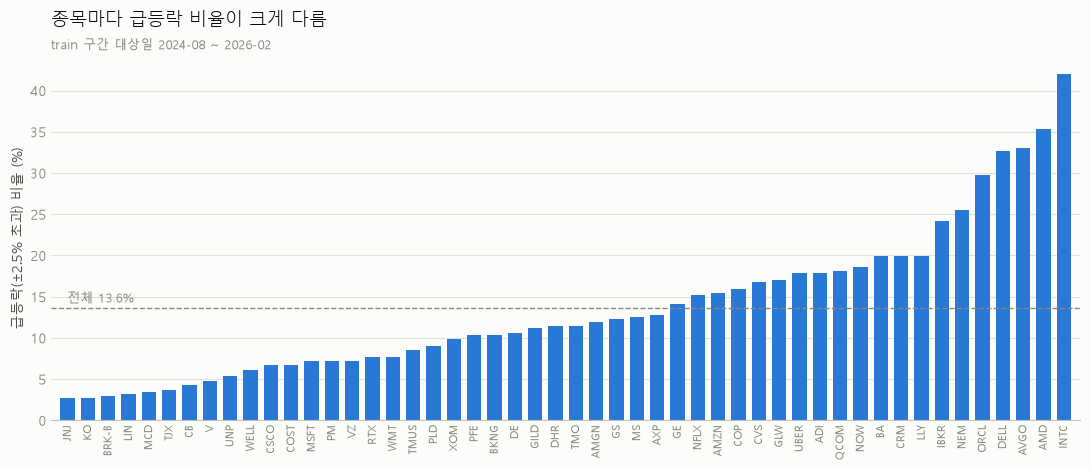

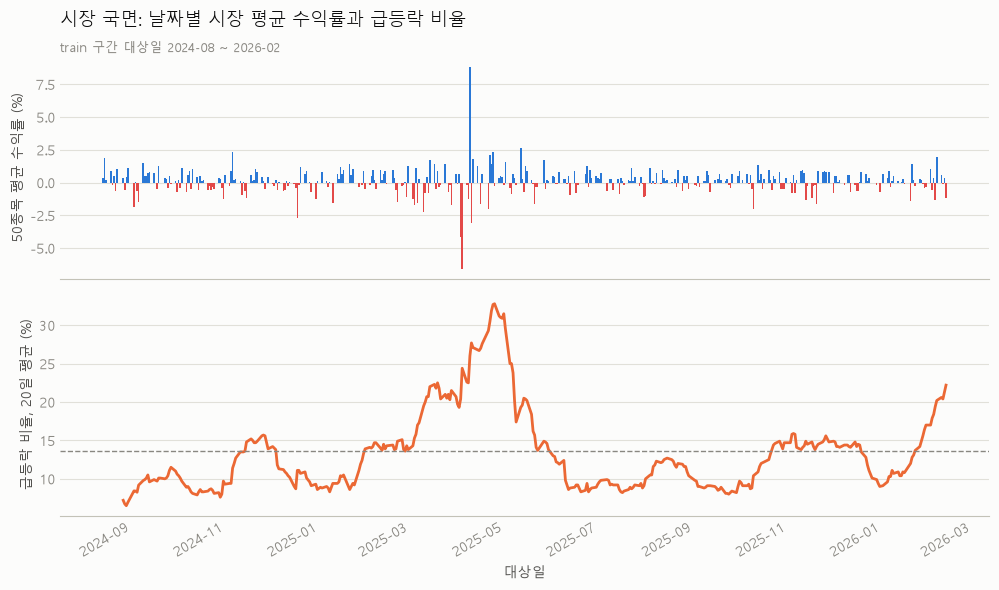

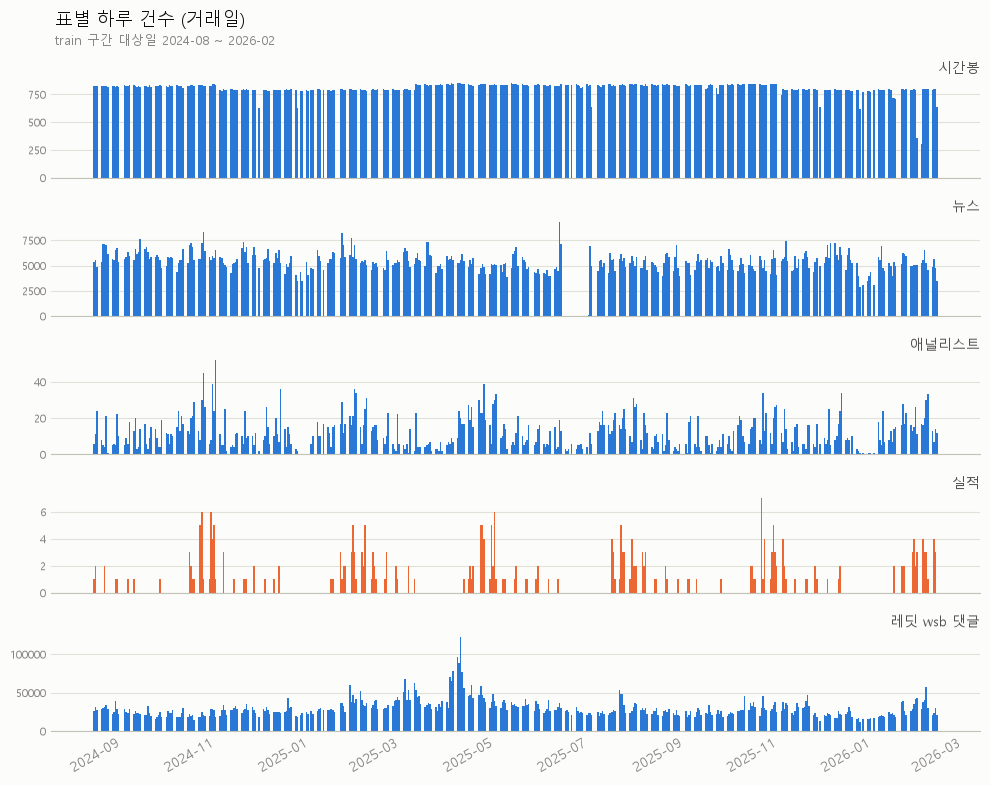

['06_symbol_bigmove.png', '07_market_regime.png', '08_coverage.png']


In [11]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
have = {f.name for f in font_manager.fontManager.ttflist}
plt.rcParams.update({"font.family": next((f for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"] if f in have), "sans-serif"),
                     "axes.unicode_minus": False})
FIGS = ROOT / "work/b/figs"; FIGS.mkdir(exist_ok=True)
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
BLUE, ORANGE, RED = "#2a78d6", "#eb6834", "#e34948"
SUB = f"train 구간 대상일 {y.date_et.min():%Y-%m} ~ {y.date_et.max():%Y-%m}"

def style(ax, title, xlabel, ylabel, fig, sub=True):
    ax.set_facecolor(SURFACE); fig.set_facecolor(SURFACE)
    if title:
        ax.set_title(title, loc="left", color=INK, fontsize=13, pad=22 if sub else 10)
    if sub:
        ax.text(0, 1.02, SUB, transform=ax.transAxes, color=MUTED, fontsize=9)
    ax.set_xlabel(xlabel, color=INK2); ax.set_ylabel(ylabel, color=INK2)
    ax.tick_params(colors=MUTED, length=0); ax.grid(axis="y", color=GRID, linewidth=0.8); ax.set_axisbelow(True)
    for s_ in ["top", "right", "left"]:
        ax.spines[s_].set_visible(False)
    ax.spines["bottom"].set_color(AXIS)

# 6) 종목별 급등락 비율
s6 = sym["급등락%"].sort_values()
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(range(len(s6)), s6.values, width=0.7, color=BLUE)
ax.axhline(y.big.mean() * 100, color=MUTED, linewidth=1, linestyle="--")
ax.annotate(f"전체 {y.big.mean()*100:.1f}%", (0, y.big.mean() * 100), xytext=(0, 4), textcoords="offset points", color=MUTED, fontsize=9)
ax.set_xticks(range(len(s6)), s6.index, rotation=90, fontsize=8)
ax.set_xlim(-0.8, len(s6) - 0.2)
style(ax, "종목마다 급등락 비율이 크게 다름", "", "급등락(±2.5% 초과) 비율 (%)", fig)
fig.tight_layout(); fig.savefig(FIGS / "06_symbol_bigmove.png", dpi=150); plt.show()

# 7) 시장 국면: 시장 평균 수익률 + 급등락 비율 20일 평균
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [1, 1]})
a1.bar(day.index, day.mkt, width=1.0, color=[RED if v < 0 else BLUE for v in day.mkt])
style(a1, "시장 국면: 날짜별 시장 평균 수익률과 급등락 비율", "", "50종목 평균 수익률 (%)", fig)
a2.plot(day.index, day.big20, color=ORANGE, linewidth=2)
a2.axhline(y.big.mean() * 100, color=MUTED, linewidth=1, linestyle="--")
style(a2, "", "대상일", "급등락 비율, 20일 평균 (%)", fig, sub=False)
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIGS / "07_market_regime.png", dpi=150); plt.show()

# 8) 데이터 양의 흐름 (작은 그림 5개, 축은 각자)
cols = ["시간봉", "뉴스", "애널리스트", "실적", "레딧 wsb 댓글"]
fig, axes = plt.subplots(len(cols), 1, figsize=(10, 8), sharex=True)
for i, (ax, col) in enumerate(zip(axes, cols)):
    s8 = c_td[col]
    ax.bar(s8.index, s8.values, width=1.0, color=BLUE if col != "실적" else ORANGE)
    style(ax, "", "", "", fig, sub=False)
    ax.set_title(col, loc="right", color=INK2, fontsize=10, pad=4)
    ax.tick_params(axis="y", labelsize=8)
fig.autofmt_xdate(); fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.text(0.06, 0.975, "표별 하루 건수 (거래일)", color=INK, fontsize=13, va="top")
fig.text(0.06, 0.945, SUB, color=MUTED, fontsize=9, va="top")
fig.savefig(FIGS / "08_coverage.png", dpi=150); plt.show()
print(sorted(p_.name for p_ in FIGS.glob("0[6-8]*.png")))